# 📊 DỰ ÁN KHAI PHÁ DỮ LIỆU: DỰ ĐOÁN THU NHẬP CÓ VƯỢT 50K/NĂM

## Mục tiêu
Xây dựng mô hình máy học để **dự đoán liệu một người có kiếm được trên 50K USD/năm hay không** dựa trên các đặc tính nhân khẩu học từ cơ sở dữ liệu Điều tra Dân số Mỹ năm 1994.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV,  RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

## 1️⃣ TẢI VÀ KHÁM PHÁ DỮ LIỆU

**Nguồn dữ liệu**: UCI Machine Learning Repository [link](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset/data)
- **Số mẫu**: ~30,000 người trưởng thành
- **Số đặc tính**: 15 biến
- **Biến mục tiêu**: income (<=50K hoặc >50K)

In [2]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
print(df.isnull().sum() * 100)

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [5]:
# print(df.describe())
# list all col type string
col = df.select_dtypes(include=['object']).columns.tolist()
col
# print('String columns:')
# for c in col: 
#     print(df[c].unique())

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'income']

## 2️⃣ DATA CLEANING

In [6]:
# Xử lý missing values
df['age'] = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)
# in this data have
df_clean = df.copy()
for c in col:
    mean_col = df[c].mode()[0]
    df_clean[c] = df_clean[c].replace("?", mean_col) 

col2 = df_clean.select_dtypes(include=['object']).columns.tolist()
for c in col2:
    print(df_clean[c].unique())
# Đổi tên cột
df_clean['predclass'] = df_clean['income']
del df_clean['income']
df_clean['education-num'] = df_clean['educational-num']
del df_clean['educational-num']

print(f"\n✅ Dữ liệu sau làm sạch:")
print(df_clean.info())

<StringArray>
[         'Private',        'Local-gov', 'Self-emp-not-inc',
      'Federal-gov',        'State-gov',     'Self-emp-inc',
      'Without-pay',     'Never-worked']
Length: 8, dtype: str
<StringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str
<StringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str
<StringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
    'Prof-specialty',     'Other-service',      'Craft-repair',
      'Adm-clerical',   'Exec-managerial',      'Tech-support',
             'Sales',   'Priv-house-serv',  'Transport-moving',
 'Handlers-cleaners'

In [7]:
df_clean['education'].unique()

<StringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str

In [8]:
## 3️⃣ KỸ THUẬT NHÂN TẠO ĐẶC TÍNH (FEATURE ENGINEERING)

print("📚 Gom nhóm Education...")
dropout_levels = ['Preschool', '10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th']
for level in dropout_levels:
    df_clean['education'] = df_clean['education'].replace(level, 'dropout')

df_clean['education'] = df_clean['education'].replace(['HS-Grad', 'HS-grad'], 'HighGrad')
df_clean['education'] = df_clean['education'].replace(['Some-college', 'Assoc-acdm', 'Assoc-voc'], 'CommunityCollege')
df_clean['education'] = df_clean['education'].replace(['Prof-school'], 'Masters')

print("✅ Các mức education sau gom nhóm:")
print(df_clean['education'].value_counts())

📚 Gom nhóm Education...
✅ Các mức education sau gom nhóm:
education
HighGrad            15784
CommunityCollege    14540
Bachelors            8025
dropout              6408
Masters              3491
Doctorate             594
Name: count, dtype: int64


In [9]:
print("\n💍 Gom nhóm Marital Status...")
df_clean['marital-status'] = df_clean['marital-status'].replace('Never-married', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Married-AF-spouse', 'Married-civ-spouse'], 'Married'
)
df_clean['marital-status'] = df_clean['marital-status'].replace('Married-spouse-absent', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Separated', 'Divorced'], 'Separated'
)

print("✅ Các tình trạng hôn nhân sau gom nhóm:")
print(df_clean['marital-status'].value_counts())


💍 Gom nhóm Marital Status...
✅ Các tình trạng hôn nhân sau gom nhóm:
marital-status
Married       22416
NotMarried    16745
Separated      8163
Widowed        1518
Name: count, dtype: int64


In [10]:
print("\n🎯 Tạo đặc tính phân chia (Binned Features)...")
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=20)
df_clean['hours-per-week_bin'] = pd.cut(df_clean['hours-per-week'], bins=10)
df_clean['age-hours'] = df_clean['age'] * df_clean['hours-per-week']

print("✅ Các đặc tính tương tác được tạo")


🎯 Tạo đặc tính phân chia (Binned Features)...
✅ Các đặc tính tương tác được tạo


## 4️⃣ PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

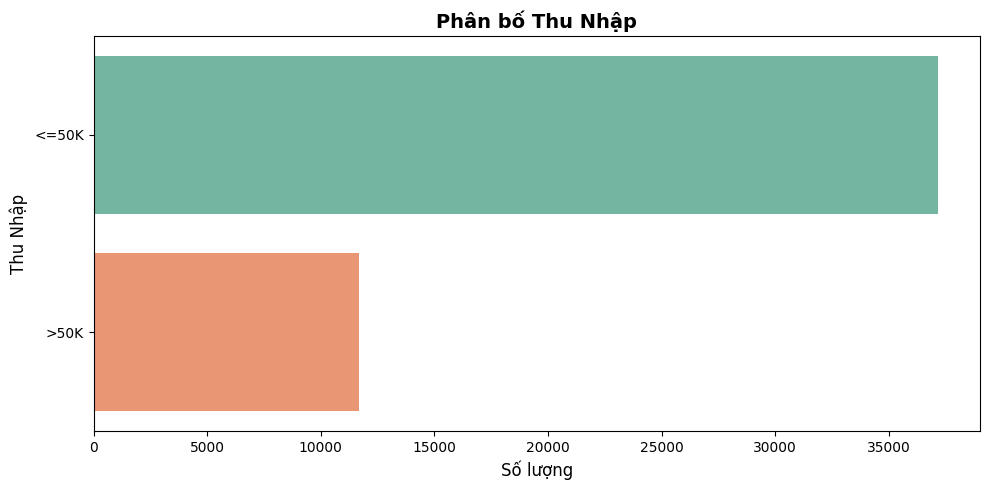

📊 Thống kê thu nhập:
predclass
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [11]:
# Draw distribution of target variable
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='predclass', palette='Set2')
plt.title('Phân bố Thu Nhập', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Thu Nhập', fontsize=12)
plt.tight_layout()
plt.show()

print("📊 Thống kê thu nhập:")
print(df_clean['predclass'].value_counts())

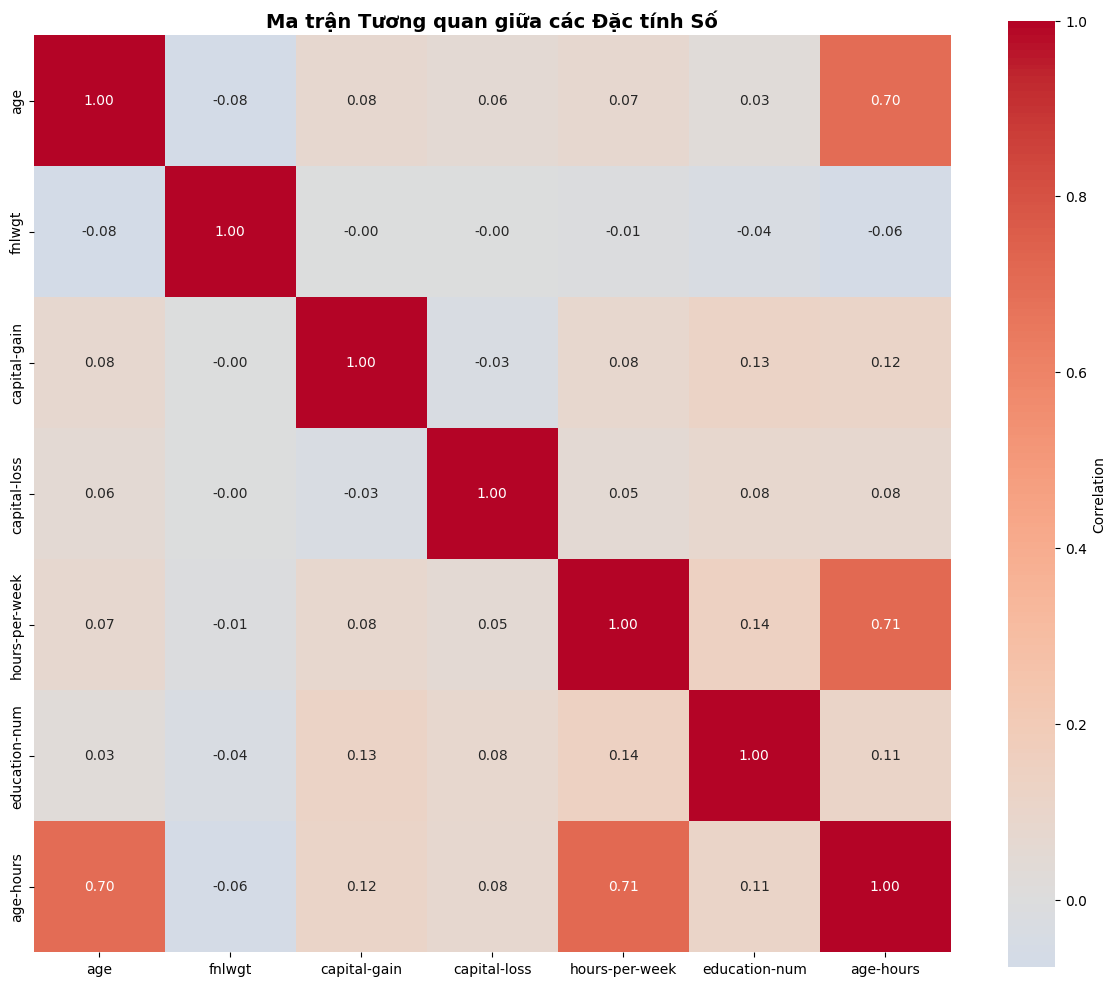

In [12]:
# Tương quan giữa các đặc tính
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Ma trận Tương quan giữa các Đặc tính Số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

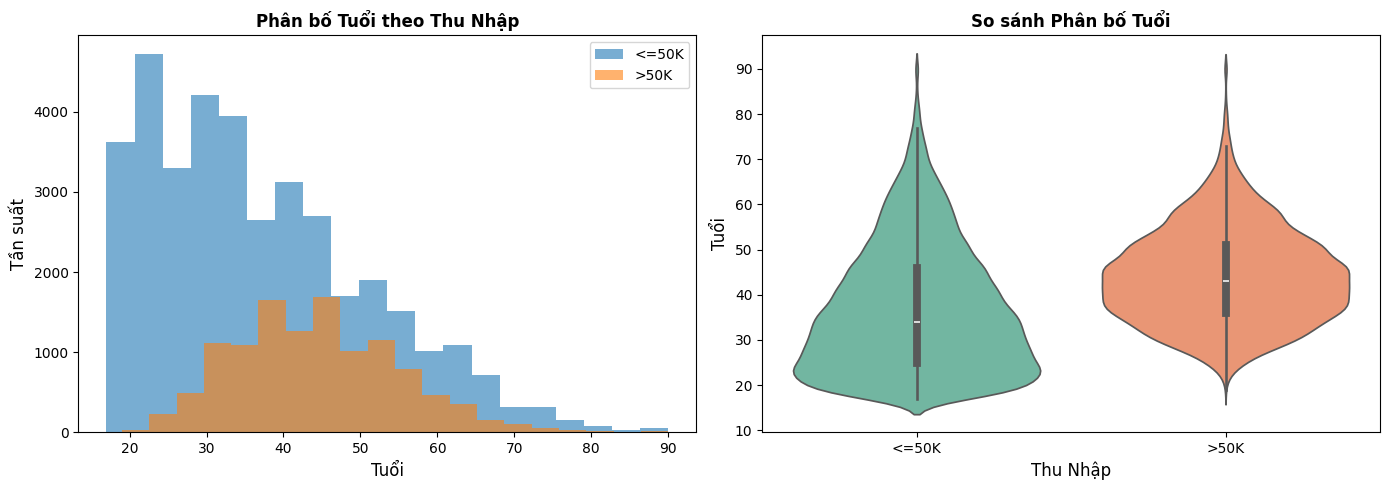

📊 Tuổi trung bình theo thu nhập:
predclass
<=50K    36.872184
>50K     44.275178
Name: age, dtype: float64


In [13]:
# Phân bố tuổi theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['age']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Tuổi theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()

sns.violinplot(data=df_clean, x='predclass', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Phân bố Tuổi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Tuổi', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Tuổi trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['age'].mean())

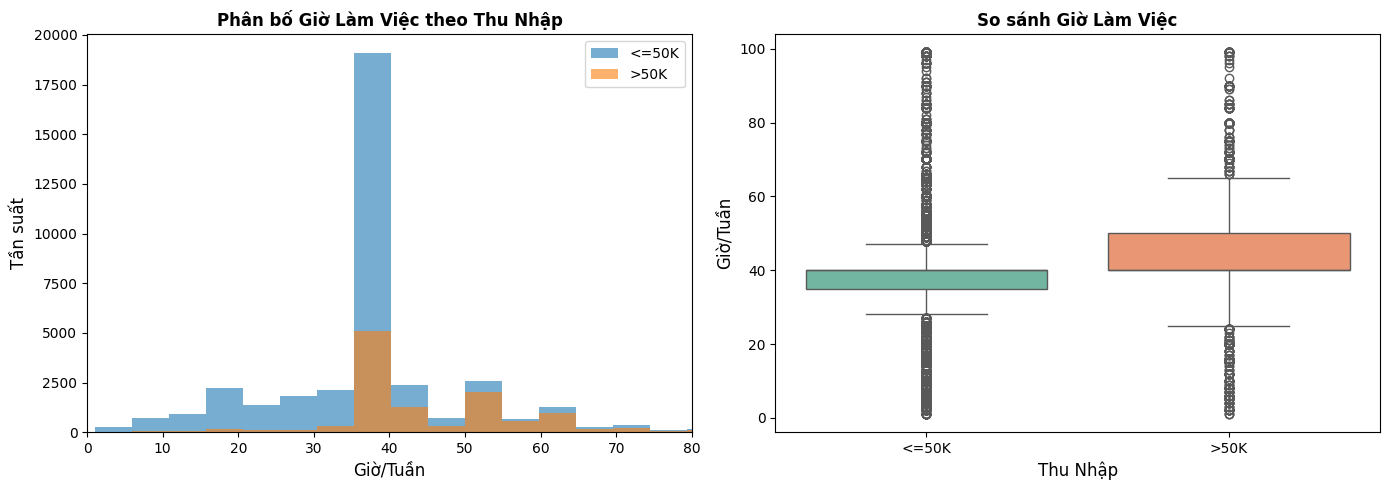

📊 Giờ làm việc trung bình theo thu nhập:
predclass
<=50K    38.840048
>50K     45.452896
Name: hours-per-week, dtype: float64


In [14]:
# Giờ làm việc theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['hours-per-week']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Giờ/Tuần', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Giờ Làm Việc theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 80)

sns.boxplot(data=df_clean, x='predclass', y='hours-per-week', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Giờ Làm Việc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Giờ/Tuần', fontsize=12)

plt.tight_layout()
plt.show()
print("📊 Giờ làm việc trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['hours-per-week'].mean())

## 5️⃣ TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)

In [15]:
print("🔹 Lựa chọn đặc tính cho mô hình...")
df_model = df_clean.copy()

# Áp dụng Label Encoding cho tất cả cột
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(df_model.head())

🔹 Lựa chọn đặc tính cho mô hình...
    age  workclass  fnlwgt  education  marital-status  occupation  \
0  25.0          3  226802          5               1           6   
1  38.0          3   89814          3               0           4   
2  28.0          1  336951          1               0          10   
3  44.0          3  160323          1               0           6   
4  18.0          3  103497          1               1           9   

   relationship  race  gender  capital-gain  capital-loss  hours-per-week  \
0             3     2       1             0             0            40.0   
1             0     4       1             0             0            50.0   
2             0     4       1             0             0            40.0   
3             0     2       1          7688             0            40.0   
4             3     4       0             0             0            30.0   

   native-country  predclass  education-num          age_bin  \
0              38      

## 6️⃣ CHIA DỮ LIỆU TRAIN-TEST

In [16]:
# Chuẩn bị X (features) và y (target)
drop_cols = ['education', 'native-country', 'predclass', 
             'age_bin', 'hours-per-week_bin']

X = df_model.drop(drop_cols, axis=1, errors='ignore')
y = df_model['predclass']

# Traning set: 24,579 mẫu (80%)
# Test set: 6,145 mẫu (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Kích thước X: {X.shape}")
print(f"📊 Training set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")

📊 Kích thước X: (48842, 13)
📊 Training set: (39073, 13)
📊 Test set: (9769, 13)


## 7️⃣ PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)

📊 Áp dụng PCA...


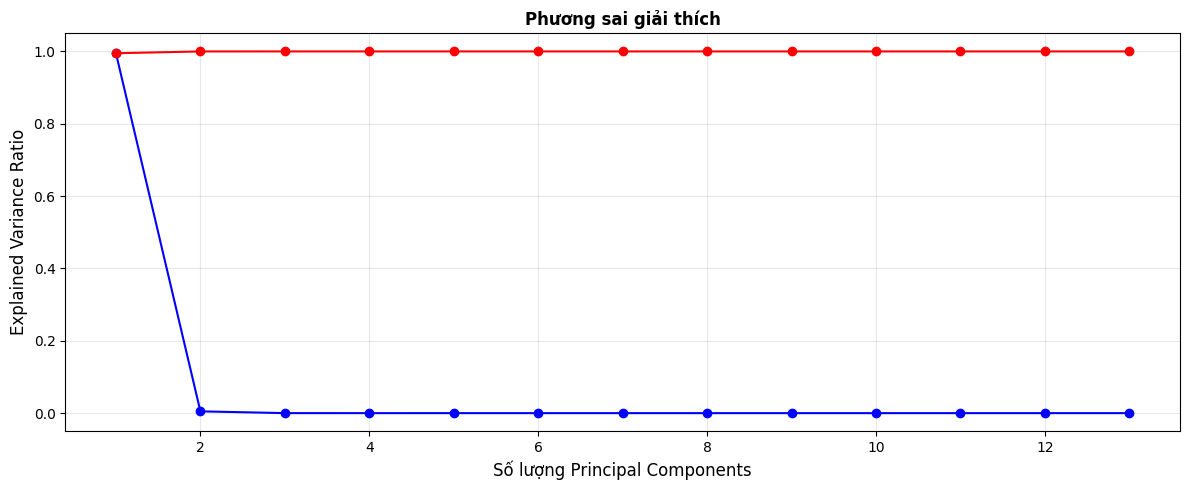


🔍 Số components để giữ 95% phương sai: 1
    (từ tổng 13 features)


In [17]:
print("📊 Áp dụng PCA...")
pca = PCA()
X_pca = pca.fit_transform(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
#          pca.explained_variance_ratio_, 'bo-')
plt.plot(range(1, len(cumsum) + 1), pca.explained_variance_ratio_, 'bo-')
plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')

plt.xlabel('Số lượng Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Phương sai giải thích', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
# plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
# plt.xlabel('Số lượng Principal Components', fontsize=12)
# plt.ylabel('Cumulative Explained Variance', fontsize=12)
# plt.title('Phương sai tích lũy', fontsize=12, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n🔍 Số components để giữ 95% phương sai: {n_components_95}")
print(f"    (từ tổng {len(pca.explained_variance_ratio_)} features)")

## 8️⃣ XÂY DỰNG VÀ HUẤN LUYỆN 7 MÔ HÌNH ML

In [18]:
print("🔹 Perceptron")

print("\n🔹 Gaussian Naive Bayes")

print("\n🔹 Linear SVM")

print("\n🔹 Radial SVM (RBF)")

print("\n🔹 Logistic Regression")

print("\n🔹 Random Forest")

print("\n🔹 K-Nearest Neighbors")


🔹 Perceptron

🔹 Gaussian Naive Bayes

🔹 Linear SVM

🔹 Radial SVM (RBF)

🔹 Logistic Regression

🔹 Random Forest

🔹 K-Nearest Neighbors


## 9️⃣ SO SÁNH CÁC MÔ HÌNH VÀ ĐÁNH GIÁ KẾT QUẢ

In [ ]:
print("📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:")
print("="*60)

models_comparison = pd.DataFrame({
    'Mô hình': [
        'Perceptron',
        'Gaussian Naive Bayes',
        # 'Linear SVM',
        # 'Radial SVM',
        # 'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Test Accuracy': [
        ppn_acc,
        gnb_acc,
        # svm_linear_acc,
        # svm_rbf_acc,
        # lr_acc,
        rf_acc,
        knn_acc
    ]
})

models_comparison = models_comparison.sort_values('Test Accuracy', ascending=False)
print(models_comparison.to_string(index=False))
print("="*60)

best_model_name = models_comparison.iloc[0]['Mô hình']
best_acc = models_comparison.iloc[0]['Test Accuracy']
print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"   Độ chính xác (Test): {best_acc:.4f} ({best_acc*100:.2f}%)")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
bars = plt.barh(models_comparison['Mô hình'], models_comparison['Test Accuracy'], color='steelblue')
bars[0].set_color('gold')

plt.xlabel('Độ Chính Xác (Accuracy)', fontsize=12, fontweight='bold')
plt.title('So sánh Độ Chính Xác của 7 Mô Hình Machine Learning', fontsize=14, fontweight='bold')
plt.xlim([0.7, 0.95])

for i, (name, acc) in enumerate(zip(models_comparison['Mô hình'], models_comparison['Test Accuracy'])):
    plt.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:


NameError: name 'ppn_acc' is not defined

## 🔟 KIỂM ĐỊNH CHÉO (CROSS-VALIDATION)

In [ ]:
print("🔍 Thực hiện Cross-Validation (10-Fold)...\n")

# cv_models = [
#     ('Perceptron', Perceptron(random_state=42, max_iter=1000)),
#     ('Gaussian Naive Bayes', GaussianNB()),
#     ('Linear SVM', SVC(kernel='linear', gamma='auto', random_state=42)),
#     ('Radial SVM', SVC(kernel='rbf', gamma=0.22, random_state=42)),
#     ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
#     ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
#     ('KNN', KNeighborsClassifier(n_neighbors=9))
# ]

cv_models = [
    ('Perceptron', ppn),
    ('Gaussian Naive Bayes', gnb),
    ('Random Forest', rf),
    ('KNN', knn)
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
for name, model in cv_models:
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Mô hình': name,
        'Mean CV Score': cv_scores.mean(),
        'Std Dev': cv_scores.std(),
        'Min': cv_scores.min(),
        'Max': cv_scores.max()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean CV Score', ascending=False)
# print(cv_df.to_string(index=False))

print("📊 KẾT QUẢ CROSS-VALIDATION (10-Fold):")
print("="*90)
print(cv_df.to_string(index=False))
print("="*90)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(cv_df))
bars = ax.bar(x_pos, cv_df['Mean CV Score'], 
               yerr=cv_df['Std Dev'], 
               capsize=5, 
               color='steelblue', 
               alpha=0.7)
bars[0].set_color('green')

ax.set_xlabel('Mô Hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax.set_title('Kết Quả Cross-Validation 10-Fold của Các Mô Hình', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Mô hình'], rotation=45, ha='right')
ax.set_ylim([0.7, 0.95])
ax.grid(axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(cv_df['Mean CV Score'], cv_df['Std Dev'])):
    ax.text(i, mean + std + 0.01, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

🔍 Thực hiện Cross-Validation (10-Fold)...



NameError: name 'ppn' is not defined

## 1️⃣1️⃣ TINH CHỈNH SIÊU THAM SỐ (HYPERPARAMETER TUNING)

In [19]:
# ====================================
# CHUẨN HÓA DỮ LIỆU
# ====================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ====================================
# GAUSSIAN NAIVE BAYES
# ====================================

print("="*60)
print("MÔ HÌNH GAUSSIAN NAIVE BAYES")
print("="*60)

# Khởi tạo mô hình
gnb = GaussianNB()

# Huấn luyện
gnb.fit(X_train, y_train)

# Dự đoán
y_pred_gnb = gnb.predict(X_test)

# Accuracy
gnb_acc = accuracy_score(y_test, y_pred_gnb)

print(f"\n📈 Độ chính xác ban đầu: {gnb_acc:.4f}")

print("\n📋 Báo cáo phân loại:")
print(classification_report(y_test, y_pred_gnb))

print("\n🧩 Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred_gnb))


# ====================================
# RANDOMIZED SEARCH CV
# ====================================

print("\n" + "="*60)
print("TỐI ƯU SIÊU THAM SỐ")
print("="*60)

random_search = RandomizedSearchCV(
    GaussianNB(),
    param_distributions={
        'var_smoothing': np.logspace(0, -9, 1000)
    },
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Huấn luyện Randomized Search
random_search.fit(X_train, y_train)

print("\n✅ Tham số tốt nhất:")
print(random_search.best_params_)

print(f"\n📈 Accuracy Cross Validation tốt nhất: {random_search.best_score_:.4f}")

# Mô hình tốt nhất
best_gnb = random_search.best_estimator_

# Predict lại
y_pred_best = best_gnb.predict(X_test)

# Accuracy sau tối ưu
best_gnb_acc = accuracy_score(y_test, y_pred_best)

print(f"\n🏆 Độ chính xác sau tối ưu: {best_gnb_acc:.4f}")

MÔ HÌNH GAUSSIAN NAIVE BAYES

📈 Độ chính xác ban đầu: 0.8126

📋 Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      7479
           1       0.68      0.39      0.49      2290

    accuracy                           0.81      9769
   macro avg       0.75      0.66      0.69      9769
weighted avg       0.80      0.81      0.79      9769


🧩 Ma trận nhầm lẫn:
[[7056  423]
 [1408  882]]

TỐI ƯU SIÊU THAM SỐ

✅ Tham số tốt nhất:
{'var_smoothing': 0.0595353313081437}

📈 Accuracy Cross Validation tốt nhất: 0.8184

🏆 Độ chính xác sau tối ưu: 0.8228
